In [ ]:
End-to-End E-commerce Intelligence System: Building a Customer 360 Analytics Framework

In [5]:
#### Step 1: Data Loading and Initial Exploration

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from commonUtil import readDataset, identify_primary_key_column, handle_missing_values, remove_duplidated, verify_date_column, standarize_columns, validate_customers_column

#### Load each dataset
####Inspect structure using .head(), .info(), .describe() step-1
customers = readDataset("dataset/customers.csv") #loading customer table
category_translation = readDataset("dataset/category_translation.csv") #loading category_translation table
location = readDataset("dataset/location.csv") #loading customer table
order_item = readDataset("dataset/order_item.csv") #loading location table
orders = readDataset("dataset/orders.csv") #loading orders table
payments = readDataset("dataset/payments.csv") #loading payments table
products = readDataset("dataset/products.csv") #loading products table
reviews = readDataset("dataset/reviews.csv") #loading reviews table
sellers = readDataset("dataset/sellers.csv") #loading sellers table

### Identify primary
print("\n \n \n#### Identifying Primary key for each dataset ###")
# identify_primary_key_column(customers)# customers dataset primary key identification
# identify_primary_key_column(category_translation)# category_translation dataset primary key identification
# identify_primary_key_column(location)# location dataset primary key identification
# identify_primary_key_column(order_item)# order_item dataset primary key identification
# identify_primary_key_column(orders)# orders dataset primary key identification
# identify_primary_key_column(payments) # payments dataset primary key identification
# identify_primary_key_column(products)# products dataset prdf.isnull().sum()imary key identification
# identify_primary_key_column(reviews)# reviews dataset primary key identification
colName, msg = identify_primary_key_column(sellers)# sellers dataset primary key identification
print(colName, msg)


# #Step 2: Data Cleaning and Preprocessing
# #Handle missing values appropriately 
print("\n \n \n#### Handle missing values appropriately ###")
# handle_missing_values(customers, "customers") #Handle missing values customers dataset 
# handle_missing_values(category_translation, "category_translation") #Handle missing values category_translation dataset 
# handle_missing_values(location, "location") #Handle missing values location dataset 
# handle_missing_values(order_item, "order_item") #Handle missing values order_item dataset 
# handle_missing_values(orders, "orders") #Handle missing values orders dataset 
# handle_missing_values(payments, "payments") #Handle missing values payments dataset 
# handle_missing_values(products, "products") #Handle missing values products dataset 
# handle_missing_values(reviews,"reviews") #Handle missing values reviews dataset 
tablName, message = handle_missing_values(sellers, "sellers") #Handle missing values sellers dataset 
print(tablName, message)


# #Remove duplicated values
# ### Output
print("\n \n \n#### Remove duplicated values ###")

# remove_duplidated(customers, "customers") #Remove duplicated values customers dataset 
# remove_duplidated(category_translation, "category_translation") #Remove duplicated values category_translation dataset 
# remove_duplidated(location, "location") #Remove duplicated values location dataset 
# remove_duplidated(order_item, "order_item") #Remove duplicated values order_item dataset 
# remove_duplidated(orders, "orders") #Remove duplicated values orders dataset 
# remove_duplidated(payments, "payments") #Remove duplicated values payments dataset 
# remove_duplidated(products, "products") #Remove duplicated values products dataset 
# remove_duplidated(reviews,"reviews") #Remove duplicated values reviews dataset 
#newTable, message = remove_duplidated(sellers, "sellers") #Remove duplicated values sellers dataset 
#print("##table", newTable, message)

#Convert date columns to datetime format 
### Output
print("\n \n \n#### Convert date columns to datetime format  ###")

# verify_date_column(customers, "customers") #Remove duplicated values customers dataset 
# verify_date_column(category_translation, "category_translation") #Remove duplicated values category_translation dataset 
# verify_date_column(location, "location") #Remove duplicated values location dataset 
# verify_date_column(order_item, "order_item") #Remove duplicated values order_item dataset 
# verify_date_column(orders, "orders") #Remove duplicated values orders dataset 
# verify_date_column(payments, "payments") #Remove duplicated values payments dataset 
# verify_date_column(products, "products") #Remove duplicated values products dataset 
# verify_date_column(reviews,"reviews") #Remove duplicated values reviews dataset 
colName1, colmsg, convertDatetime = verify_date_column(sellers, "sellers") #Remove duplicated values sellers datase
print(colName1, colmsg, convertDatetime)

#Validate data types and ranges
print("\n\n##Validate data types and ranges")
validate_customers_column(customers)
print("\n")


##Standardize column names if required customers dataset
print("\n\n##Standardize column names if required customers dataset")
res = standarize_columns(customers)
#tableName = standarize_columns(location, "location")
print("\n", res )

###Step 3: Data Integration (Critical Component)
##You must construct a Master Dataset by merging multiple tables.
## orders + customers 
mergedTable1 = pd.merge(orders, customers, on="customer_id", how='left')
mergedTable2 = pd.merge(mergedTable1, order_item, on="order_id", how='left')
mergedTable3 = pd.merge(mergedTable2, products, on="product_id", how='left')
mergedTable4 = pd.merge(mergedTable3, payments, on="order_id", how='left')
mergedTable5 = pd.merge(mergedTable4, reviews , on="order_id", how='left')
mergedTable6 = pd.merge(mergedTable5, sellers , on="seller_id", how='left')
mergedTable7 = pd.merge(mergedTable6, category_translation, on="product_category_name", how='left')
#Standarizing the columns
res = standarize_columns(mergedTable7)
#REmoving duplicates
newTable  = remove_duplidated(res, "modified table") ##Final eCommerceTable
eCommereTable = newTable
print("\n#### Final merged eCommerceTable ### \n\n\n", eCommereTable)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data c

In [7]:
##Step 4: Feature Engineering

In [2]:

# ###Step 4: Feature Engineering
# ###Total order value (aggregated from order_items or payments) 
#Total order value (aggregated from payments) 
totalOrderValue = eCommerceTable["payment_value"].sum()
print("\n #### Total order value (aggregated from  payments) ### \n", totalOrderValue)

# ### Delivery time (order purchase to delivery date
print("\n ### Delivery time (order purchase to delivery date ### \n")
actualTime = ( pd.to_datetime(eCommerceTable['order_delivered_customer_date']) -  pd.to_datetime(eCommerceTable['order_purchase_timestamp']))
print(actualTime.head(5))### Delivery time (order purchase to delivery date ### 

# ### Number of items per order 
noOfItems = eCommerceTable.groupby('order_id').size()
print("\n\n ###Number of items per order \n", noOfItems.head(5))

# ### Customer purchase frequency
customerFrequency = eCommerceTable.groupby('customer_id')['order_id'].nunique()
filteredData = eCommerceTable[eCommerceTable['order_status'] == "delivered"]
filteredData = filteredData.assign(convertedDate=pd.to_datetime(filteredData['order_purchase_timestamp']))
filteredData = filteredData.sort_values(['customer_unique_id', 'convertedDate'])
print(filteredData)
print("\n ###Customer purchase frequency \n", filteredData.groupby('customer_unique_id')['convertedDate'].diff())

# ### Customer lifetime value (basic approximation) 
spendBycustomer = eCommerceTable.groupby('customer_id')['payment_value'].sum()
print("\n ###Customer lifetime value (basic approximation) \n", spendBycustomer.head())

# ###Average order value per customer
sumData = eCommerceTable['payment_value'].sum()
countData = eCommerceTable['customer_unique_id'].count()
print("\n ###Average order value per customer \n", sumData / countData) ## Calculating the avg value by taking sum of payment_value divided by count of customer (customer unique id)



 #### Total order value (aggregated from  payments) ### 
 20579664.009999998

 ### Delivery time (order purchase to delivery date ### 

0    8 days 10:28:40
1    8 days 10:28:40
2    8 days 10:28:40
3   13 days 18:46:08
4    9 days 09:27:40
dtype: timedelta64[ns]


 ###Number of items per order 
 order_id
00010242fe8c5a6d1ba2dd792cb16214    1
00018f77f2f0320c557190d7a144bdd3    1
000229ec398224ef6ca0657da4fc703e    1
00024acbcdf0a6daa1e931b038114c75    1
00042b26cf59d7ce69dfabb4e55b4fd9    1
dtype: int64
                                order_id                       customer_id  \
63195   e22acc9c116caa3f2b7121bbb380d08e  fadbb3709178fc513abc1b2670aa1ad2   
88385   3594e05a005ac4d06a72673270ef9ec9  4cb282e167ae9234755102258dd52ee8   
31704   b33ec3b699337181488304f362a6b734  9b3932a6253894a02c1df9d19004239f   
117980  41272756ecddd9a9ed0180413cc22fb6  914991f0c02ef0843c0e7010c819d642   
49813   d957021f1127559cd947b62533f484f7  47227568b10f5f58a524a75507e6992c   
...                  

In [ ]:
### Step 5: Exploratory Data Analysis (EDA)

In [4]:

### Perform structured analysis across the following dimensions:

### Customer Analysis
### ### ### New vs repeat customers 
print("\n\n ###High-value vs low-value customers ### \n")
newCoustomerCount = eCommerceTable.groupby('customer_unique_id')['order_id'].nunique().reset_index()
if (newCoustomerCount['order_id'] > 1).any():
    print("Repeat customers exist")
if (newCoustomerCount['order_id'] > 1).sum() == 0:
    print("New customers")

### High-value vs low-value customers 
print("\n\n###High-value vs low-value customers ### \n")
highLowValue = eCommerceTable.groupby('customer_unique_id').agg(
    min_payment=('payment_value', 'min'),
    max_payment=('payment_value', 'max')
).reset_index() 
print(highLowValue)

### Geographic distribution of customers
print("\n\n###Geographic distribution of customers ### \n")
geographicstateCustomers = eCommerceTable.groupby('customer_state').agg({
    "customer_id": "count"
})
geographiccityCustomers = eCommerceTable.groupby('customer_city').agg({
    "customer_id": "count"
})
# print("\n\n###Geographic distribution of customers state wise ### \n")
# print(geographicstateCustomers)
# print("\n\n###Geographic distribution of customers city wise### \n")
# print(geographiccityCustomers)

###Monthly revenue trends 
###Revenue and Order Analysis
print("\n\n ###Revenue and Order Analysis## \n")

eCommerceTable["orderconvertDate"] =  pd.to_datetime(
    eCommerceTable["order_purchase_timestamp"]
)
eCommerceTable["monthbasis"] = eCommerceTable['orderconvertDate'].dt.to_period("M")
monthly_revenue = eCommerceTable.groupby("monthbasis").agg(
     totalOrder=("order_id", "count"),
    totalRevenue=("payment_value", "sum")
).reset_index()
print(monthly_revenue)

###Order volume trends
print("\n\n ###Order volume trends monthly ## \n")
orderVolume = monthly_revenue.sort_values("totalOrder", ascending=False).reset_index()
print(orderVolume["totalOrder"].head())
###Peak sales periods 
print("\n\n ### Peak sales periods  ## \n")
print(orderVolume["totalRevenue"].head(1))

###Product Analysis
print("\n\n ### Product Analysis   ## \n")
###Top-selling product categories
print("\n\n ### Top-selling product categories  ## \n")

topSellingCategory = eCommerceTable.groupby("product_category_name").agg(
     topSellingCateg =("order_id", "count"),
    totalRevenue=("payment_value", "sum")

).reset_index()
print(topSellingCategory['product_category_name'].head(3))

print("\n\n ### Revenue contribution by category ## \n")
totalRevenue = topSellingCategory["totalRevenue"].sum()
print((topSellingCategory["totalRevenue"]/totalRevenue)*100) # revenue based on the category / totalRevenue *100

###Product demand distribution  
## By product
productBasedDemand = eCommerceTable.groupby("product_id").agg(
     demandByProduct =("order_id", "nunique"),
).reset_index()
print("\n\n ### Product demand distribution by Category ## \n")
print(productBasedDemand.sort_values("demandByProduct", ascending= False))
productCategBasedDemand = eCommerceTable.groupby("product_category_name").agg(
     demandByProductCateg =("order_id", "nunique"),
).reset_index()
print("\n\n ### Product demand distribution by product ## \n")
print(productCategBasedDemand.sort_values("demandByProductCateg", ascending= False))

## Seller Analysis
print("\n\n ### Seller Analysis ## \n")
print("\n\n Top-performing sellers")
sellerData = eCommerceTable.groupby("product_id").agg(
     sellerCount =("order_id", "nunique"),
).reset_index()
print(sellerData.sort_values("sellerCount", ascending= False))

print("\n\n ### Seller contribution to revenue  ## \n")
print("\n\n Seller contribution to revenue ")
sellerData = eCommerceTable.groupby("seller_id").agg(
     sellerContribution =("payment_value", "sum"),
).reset_index()
print(sellerData.sort_values("sellerContribution", ascending= False))

print("\n\n ### Seller distribution  ## \n")
print("\n\n Seller distribution")
sellerContriData = eCommerceTable.groupby("seller_city").agg(
     sellerContribution =("payment_value", "sum"),
).reset_index()
print(sellerContriData.sort_values("sellerContribution", ascending= False))

sellerContriData1 = eCommerceTable.groupby("seller_state").agg(
     sellerContribution =("payment_value", "sum"),
).reset_index()
print(sellerContriData1.sort_values("sellerContribution", ascending= False))



 ###High-value vs low-value customers ### 

Repeat customers exist


###High-value vs low-value customers ### 

                     customer_unique_id  min_payment  max_payment
0      0000366f3b9a7992bf8c76cfdf3221e2       141.90       141.90
1      0000b849f77a49e4a4ce2b2a4ca5be3f        27.19        27.19
2      0000f46a3911fa3c0805444483337064        86.22        86.22
3      0000f6ccb0745a6a4b88665a16c9f078        43.62        43.62
4      0004aac84e0df4da2b147fca70cf8255       196.89       196.89
...                                 ...          ...          ...
96091  fffcf5a5ff07b0908bd4e2dbc735a684      2067.42      2067.42
96092  fffea47cd6d3cc0a88bd621562a9d061        84.58        84.58
96093  ffff371b4d645b6ecea244b27531430a       112.46       112.46
96094  ffff5962728ec6157033ef9805bacc48       133.69       133.69
96095  ffffd2657e2aad2907e67c3e9daecbeb        71.56        71.56

[96096 rows x 3 columns]


###Geographic distribution of customers ### 



 ###Revenue and Or

In [6]:
##Step 6: Data Visualization



 Time series plots
     order_date  total_revenue
0    2016-09-04         136.23
1    2016-09-05          75.06
2    2016-09-13           0.00
3    2016-09-15         143.46
4    2016-10-02         109.34
..          ...            ...
629  2018-09-29           0.00
630  2018-10-01           0.00
631  2018-10-03           0.00
632  2018-10-16           0.00
633  2018-10-17           0.00

[634 rows x 2 columns]


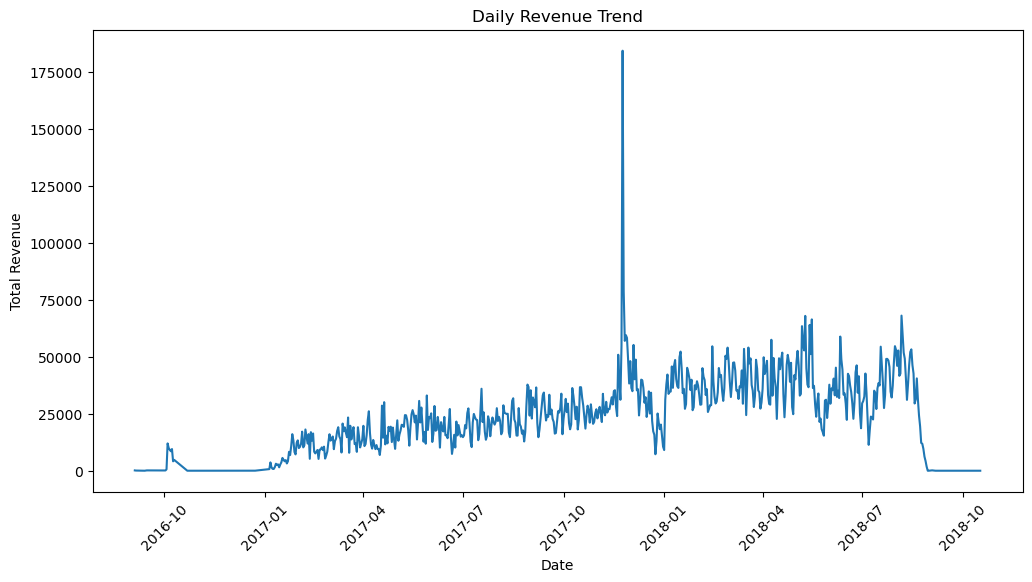



 Bar charts (category performance)


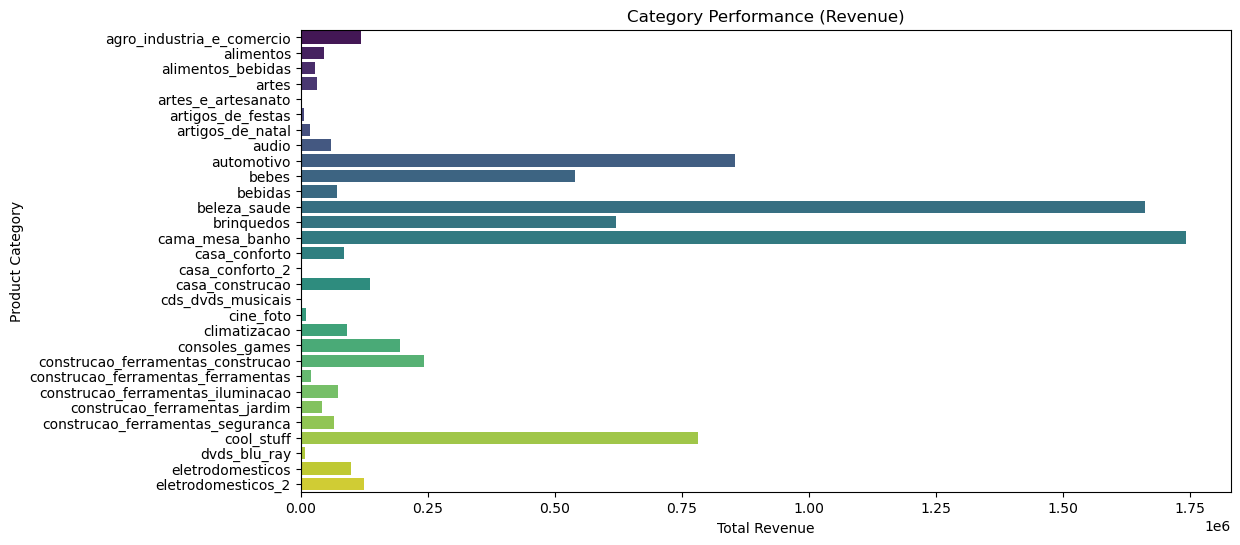



 Histograms (distribution analysis)


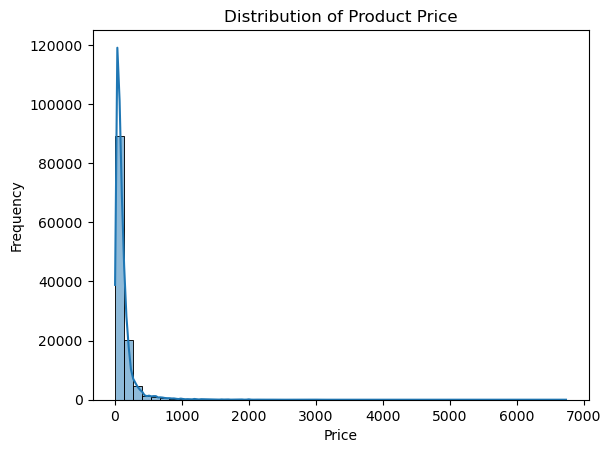

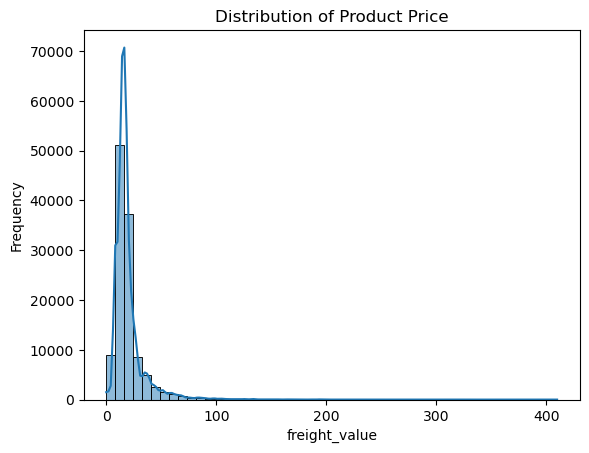



 Box plots (outlier detection) 


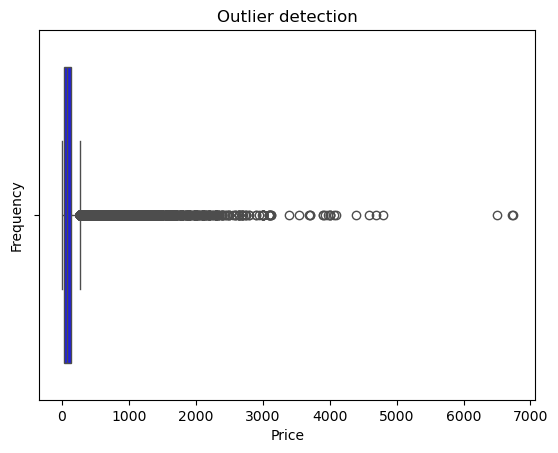



 Heatmaps (correlation analysis


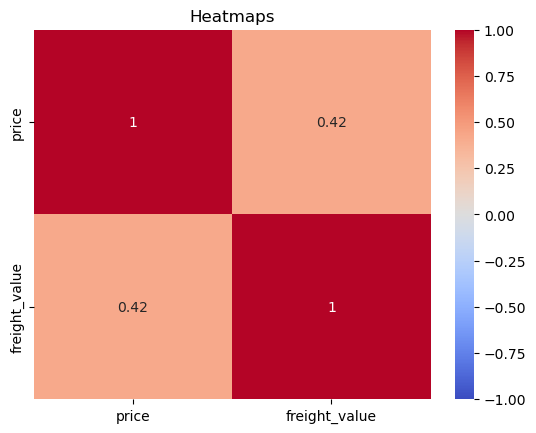

In [15]:
##Time series plots (sales trends) 
print("\n\n Time series plots")
eCommerceTable['order_purchase_timestamp'] = pd.to_datetime(
    eCommerceTable['order_purchase_timestamp'], errors='coerce'
)
eCommerceTable['order_date'] = eCommerceTable['order_purchase_timestamp'].dt.date
eCommerceTable['total_revenue'] = eCommerceTable['price'] + eCommerceTable['freight_value']
daily_revenue = eCommerceTable.groupby('order_date')['total_revenue'].sum().reset_index()
print(daily_revenue)
###plot chart
plt.figure(figsize=(12,6))
sns.lineplot(data=daily_revenue, x='order_date', y='total_revenue')
plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

####Bar charts (category performance)
print("\n\n Bar charts (category performance)")

categPerformance = eCommerceTable.groupby("product_category_name").agg(
     topSellingCateg =("order_id", "count"),
    totalRevenue=("payment_value", "sum"),
    avgPrice=('price', 'mean')
).reset_index()
categPerformance['totalRevenue'] = pd.to_numeric(categPerformance['totalRevenue'], errors='coerce')
categPerformance = categPerformance.dropna(subset=['totalRevenue', 'product_category_name'])
plt.figure(figsize=(12,6))

sns.barplot(
    data=categPerformance.head(30),
    x='totalRevenue',
    y='product_category_name',
    palette='viridis',
      hue='product_category_name',
)

plt.title('Category Performance (Revenue)')
plt.xlabel('Total Revenue')
plt.ylabel('Product Category')
plt.show()

###Histograms (distribution analysis) 
print("\n\n Histograms (distribution analysis)")
###Price based histogram
sns.histplot(
    data=eCommerceTable,
    x='price',
    bins=50,
    kde=True
)

plt.title('Distribution of Product Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

###freight_value based histogram
sns.histplot(
    data=eCommerceTable,
    x='freight_value',
    bins=50,
    kde=True
)

plt.title('Distribution of Product Price')
plt.xlabel('freight_value')
plt.ylabel('Frequency')
plt.show()

###Box plots (outlier detection)  
print("\n\n Box plots (outlier detection) ")
###Price based histogram
sns.boxplot(
    data=eCommerceTable,
    x='price',
    color="blue"
)

plt.title('Outlier detection')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

##Heatmaps (correlation analysis) 
print("\n\n Heatmaps (correlation analysis") 
numeric_data = eCommerceTable[['price', 'freight_value']]
corr_matrix = numeric_data.corr()
sns.heatmap(
    corr_matrix,
    annot=True,        
    cmap='coolwarm',   
    vmin=-1, vmax=1    
)
plt.title('Heatmaps')
plt.show()
